# Motion-Aware Video Object Replacement with GANs (Adjusted for `frames.zip`)

This notebook is a **GAN-based** demo for *video object replacement*.

## What’s changed vs the original Kaggle version
- Works with your uploaded dataset **`/mnt/data/frames.zip`** (image frames organized by category/sequence), not `/kaggle/input`.
- Lets you pick a sequence from **cats / humans / cars** and automatically sets the segmentation class.
- Lets you replace the segmented object with a **drone** or **car**.
  - If you don't provide a PNG, the notebook will generate a simple transparent **RGBA** icon for the chosen replacement object.

## High-level pipeline
1. Load frames from a selected sequence.
2. Segment the *source* object per frame using **YOLOv8-seg** (COCO classes).
3. Build a background initialization (inpainting) + object layer.
4. Train a small pix2pix-style GAN (self-supervised) to reconstruct the original frames.
5. Swap in the replacement object layer and run the generator to blend it into the scene.

> Tip: start with a small `MAX_FRAMES` and `EPOCHS` to verify the pipeline, then increase for quality.


In [29]:
# =========================
# 0) Install dependencies
# =========================
!pip -q install ultralytics tqdm einops


In [30]:
# =========================
# 1) Imports & configuration
# =========================
import os, glob, math, re, zipfile
from typing import List, Tuple, Optional

import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

from ultralytics import YOLO

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# -------------------------
# User settings (edit me)
# -------------------------

# 1) Dataset location (your upload)

# 2) Choose which sequence to run
#    Available top-level categories in your zip: "cats", "humans", "cars"
DATA_CATEGORY = "cats"                          # "cats" | "humans" | "cars"
SEQUENCE_NAME = None                           # e.g. "cats__vid1_960x540_30fps" (None = auto-pick first)

# 3) Object to SEGMENT (source object in the frames)
#    If None, will be auto-mapped from DATA_CATEGORY:
#      cats   -> "cat"
#      humans -> "person"
#      cars   -> "car"
TARGET_CLASS_NAME = None                        # override if needed, must be a COCO class name

CONF_THRES = 0.25
IMG_SIZE = 512                                  # train/infer resolution (square letterbox)
MAX_FRAMES = 200                                # keep small for demo; increase if you want
EPOCHS = 2                                      # increase for better blending
BATCH_SIZE = 2
LR = 2e-4

# 4) Replacement object (what you want to INSERT)
REPLACEMENT_OBJECT = "drone"                    # "drone" | "car"
REPLACEMENT_IMAGE_PATH = None                   # optional: path to a PNG/JPG. If None, we'll generate a simple RGBA icon.
EXTRACT_DIR="/kaggle/input/frames-gans"
# 5) Where to store caches + outputs
WORK_DIR = "/kaggle/input/frames-gans"
os.makedirs(WORK_DIR, exist_ok=True)
print("WORK_DIR:", WORK_DIR)


Device: cuda
WORK_DIR: /kaggle/input/frames-gans


Saved replacement image to: /kaggle/working/gan_replace_work/assets/drone.png
Saved processed RGBA drone to: /kaggle/working/gan_replace_work/assets/drone_rgba.png


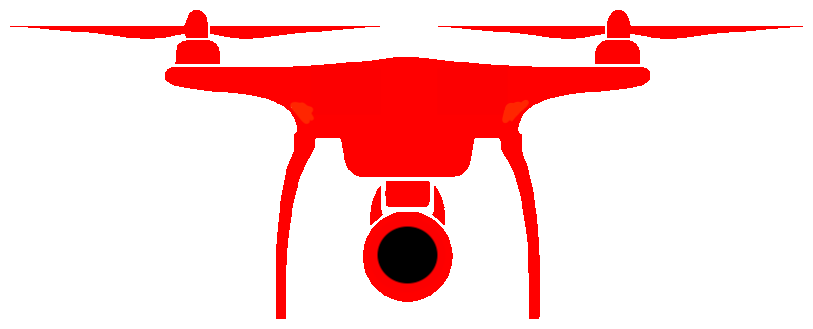

In [31]:
# --- Download a drone PNG from the internet (Kaggle) + ensure RGBA ---
import os
import numpy as np
from PIL import Image
import cv2
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import urllib.request

# Writable dir on Kaggle
WORK_DIR = "/kaggle/working/gan_replace_work"
os.makedirs(WORK_DIR, exist_ok=True)

assets_dir = os.path.join(WORK_DIR, "assets")
os.makedirs(assets_dir, exist_ok=True)

# Stable direct PNG (Wikimedia upload CDN)
REPLACEMENT_IMAGE_URL = "https://upload.wikimedia.org/wikipedia/commons/1/11/Droneicon.png"
dst_path = os.path.join(assets_dir, "drone.png")

def download_file(url: str, out_path: str):
    # 1) requests with retries
    session = requests.Session()
    retries = Retry(
        total=5, connect=5, read=5,
        backoff_factor=0.8,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"]
    )
    session.mount("https://", HTTPAdapter(max_retries=retries))
    session.mount("http://", HTTPAdapter(max_retries=retries))

    headers = {"User-Agent": "Mozilla/5.0 (Kaggle Notebook)"}
    try:
        r = session.get(url, headers=headers, timeout=60, stream=True)
        r.raise_for_status()
        with open(out_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 256):
                if chunk:
                    f.write(chunk)
        return

    except Exception as e:
        print("requests download failed:", repr(e))
        print("Trying urllib fallback...")

    # 2) urllib fallback
    req = urllib.request.Request(url, headers=headers)
    with urllib.request.urlopen(req, timeout=60) as resp, open(out_path, "wb") as f:
        f.write(resp.read())

# Download once
if not os.path.exists(dst_path):
    download_file(REPLACEMENT_IMAGE_URL, dst_path)

REPLACEMENT_IMAGE_PATH = dst_path
print("Saved replacement image to:", REPLACEMENT_IMAGE_PATH)

# Load and ensure RGBA
im = Image.open(REPLACEMENT_IMAGE_PATH).convert("RGBA")
rgba = np.array(im)

# If alpha is fully opaque, remove flat background by corner color-key
alpha = rgba[..., 3]
if alpha.min() == 255 and alpha.max() == 255:
    rgb = rgba[..., :3].astype(np.int16)
    H, W = rgb.shape[:2]
    corners = np.stack([rgb[0,0], rgb[0,W-1], rgb[H-1,0], rgb[H-1,W-1]], axis=0)
    bg = np.median(corners, axis=0)

    dist = np.sqrt(((rgb - bg) ** 2).sum(axis=2))
    T = 30.0  # tune 20-60 if needed
    new_alpha = (dist > T).astype(np.uint8) * 255
    new_alpha = cv2.GaussianBlur(new_alpha, (0, 0), sigmaX=1.2)
    rgba[..., 3] = new_alpha

# Crop to non-transparent area (+ padding)
a = rgba[..., 3]
ys, xs = np.where(a > 10)
if len(xs) > 0 and len(ys) > 0:
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    pad = 10
    x1 = max(0, x1 - pad); y1 = max(0, y1 - pad)
    x2 = min(rgba.shape[1]-1, x2 + pad); y2 = min(rgba.shape[0]-1, y2 + pad)
    rgba = rgba[y1:y2+1, x1:x2+1]

processed_path = os.path.join(assets_dir, "drone_rgba.png")
Image.fromarray(rgba).save(processed_path)
REPLACEMENT_IMAGE_PATH = processed_path
print("Saved processed RGBA drone to:", REPLACEMENT_IMAGE_PATH)

# Visual check
Image.open(REPLACEMENT_IMAGE_PATH)


In [32]:
# =========================
# 2) Prepare dataset (Kaggle directory structure: /kaggle/input/frames-gans/frames/<category>/<sequence>/<frame>.jpg)
# =========================
import os, glob, shutil
from tqdm import tqdm

# Kaggle input is read-only. We'll *read* frames from there, and optionally copy the selected sequence to EXTRACT_DIR (writable).
DATA_ROOT = "/kaggle/input/frames-gans/frames"  # <-- this is your structure
assert os.path.isdir(DATA_ROOT), f"Missing folder: {DATA_ROOT}"

os.makedirs(EXTRACT_DIR, exist_ok=True)

# List categories
cats = sorted([d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d))])
print("Available categories:", cats)

if DATA_CATEGORY not in cats:
    raise ValueError(f"DATA_CATEGORY='{DATA_CATEGORY}' not found. Pick one of: {cats}")

# List sequences under the chosen category
cat_dir = os.path.join(DATA_ROOT, DATA_CATEGORY)
seqs = sorted([d for d in os.listdir(cat_dir) if os.path.isdir(os.path.join(cat_dir, d))])
print(f"Available sequences under '{DATA_CATEGORY}':")
for s in seqs:
    print(" -", s)

if len(seqs) == 0:
    raise RuntimeError(f"No sequences found under: {cat_dir}")

if SEQUENCE_NAME is None:
    SEQUENCE_NAME = seqs[0]
    print("Auto-picked SEQUENCE_NAME =", SEQUENCE_NAME)
elif SEQUENCE_NAME not in seqs:
    raise ValueError(f"SEQUENCE_NAME='{SEQUENCE_NAME}' not found for category '{DATA_CATEGORY}'.")

# Source (read-only) sequence directory in Kaggle input
SEQ_DIR_IN = os.path.join(cat_dir, SEQUENCE_NAME)
assert os.path.isdir(SEQ_DIR_IN), f"Missing sequence directory: {SEQ_DIR_IN}"

# Collect frames
frame_paths_in = sorted(
    glob.glob(os.path.join(SEQ_DIR_IN, "*.jpg")) +
    glob.glob(os.path.join(SEQ_DIR_IN, "*.jpeg")) +
    glob.glob(os.path.join(SEQ_DIR_IN, "*.png"))
)
if len(frame_paths_in) == 0:
    raise RuntimeError(f"No image frames found in: {SEQ_DIR_IN}")

print("Found frames:", len(frame_paths_in))
print("Example frame:", frame_paths_in[0])

# If your pipeline needs writable access in the same folder (some notebooks do), copy selected sequence to EXTRACT_DIR
COPY_TO_WORKDIR = False  # set True if later cells need to write alongside frames
if COPY_TO_WORKDIR:
    SEQ_DIR = os.path.join(EXTRACT_DIR, DATA_CATEGORY, SEQUENCE_NAME)
    os.makedirs(SEQ_DIR, exist_ok=True)

    # Copy only missing frames
    missing = 0
    for src in frame_paths_in:
        dst = os.path.join(SEQ_DIR, os.path.basename(src))
        if not os.path.exists(dst):
            missing += 1

    if missing > 0:
        print(f"Copying {missing}/{len(frame_paths_in)} frames -> {SEQ_DIR}")
        for src in tqdm(frame_paths_in, desc="Copying"):
            dst = os.path.join(SEQ_DIR, os.path.basename(src))
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
    else:
        print("All frames already copied for this sequence.")

    frame_paths = sorted(
        glob.glob(os.path.join(SEQ_DIR, "*.jpg")) +
        glob.glob(os.path.join(SEQ_DIR, "*.jpeg")) +
        glob.glob(os.path.join(SEQ_DIR, "*.png"))
    )
else:
    SEQ_DIR = SEQ_DIR_IN
    frame_paths = frame_paths_in

print("Selected sequence directory:", SEQ_DIR)
print("Using frames:", len(frame_paths))

# Auto-map segmentation class from category if not provided
if TARGET_CLASS_NAME is None:
    mapping = {"cats": "cat", "humans": "person", "cars": "car"}
    TARGET_CLASS_NAME = mapping.get(DATA_CATEGORY, "person")
print("TARGET_CLASS_NAME =", TARGET_CLASS_NAME)


Available categories: ['cars', 'cats', 'humans']
Available sequences under 'cats':
 - cats__vid1_960x540_30fps
 - cats__vid2_960x540_30fps
 - cats__vid3_960x540_30fps
 - cats__vid4_960x540_30fps
 - cats__vid5_960x540_30fps
 - cats__vid6_960x540_30fps
Auto-picked SEQUENCE_NAME = cats__vid1_960x540_30fps
Found frames: 300
Example frame: /kaggle/input/frames-gans/frames/cats/cats__vid1_960x540_30fps/00001.jpg
Selected sequence directory: /kaggle/input/frames-gans/frames/cats/cats__vid1_960x540_30fps
Using frames: 300
TARGET_CLASS_NAME = cat


In [33]:
# =========================
# 3) Frame IO utilities (directory of jpg/png frames OR a video)
# =========================
def read_frames_dir(frames_dir: str, max_frames: Optional[int] = None) -> List[np.ndarray]:
    exts = ("*.jpg", "*.jpeg", "*.png")
    paths = []
    for e in exts:
        paths.extend(glob.glob(os.path.join(frames_dir, e)))
    if len(paths) == 0:
        # recursive fallback
        for e in exts:
            paths.extend(glob.glob(os.path.join(frames_dir, "**", e), recursive=True))
    if len(paths) == 0:
        raise FileNotFoundError(f"No image frames found under: {frames_dir}")

    def frame_key(p: str):
        # sort by numeric filename if possible (00001.jpg etc)
        base = os.path.splitext(os.path.basename(p))[0]
        m = re.search(r"(\d+)$", base)
        return int(m.group(1)) if m else base

    paths = sorted(paths, key=frame_key)
    if max_frames is not None:
        paths = paths[:max_frames]

    frames = []
    for p in tqdm(paths, desc="Loading frames"):
        bgr = cv2.imread(p, cv2.IMREAD_COLOR)
        if bgr is None:
            continue
        frames.append(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    if len(frames) == 0:
        raise RuntimeError("Loaded 0 frames (all reads failed).")
    return frames

def parse_fps_from_name(name: str, default: float = 30.0) -> float:
    # tries to parse '30fps' from SEQUENCE_NAME
    m = re.search(r"(\d+(?:\.\d+)?)fps", name.lower())
    return float(m.group(1)) if m else float(default)

def write_video_cv2(frames_rgb: List[np.ndarray], fps: float, out_path: str) -> None:
    if len(frames_rgb) == 0:
        raise ValueError("No frames to write.")
    h, w, _ = frames_rgb[0].shape
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_path, fourcc, fps, (w, h))
    for fr in frames_rgb:
        fr_bgr = cv2.cvtColor(fr, cv2.COLOR_RGB2BGR)
        writer.write(fr_bgr)
    writer.release()

# ---- Load frames from the selected sequence directory ----
fps = parse_fps_from_name(SEQUENCE_NAME, default=30.0)
frames = read_frames_dir(SEQ_DIR, max_frames=MAX_FRAMES)
print(f"Loaded {len(frames)} frames. Assumed FPS={fps:.2f}. Frame shape: {frames[0].shape}")


Loading frames: 100%|██████████| 200/200 [00:01<00:00, 141.94it/s]

Loaded 200 frames. Assumed FPS=30.00. Frame shape: (540, 960, 3)


In [34]:
# =========================
# 4) YOLOv8-seg: segment target object per frame
# =========================
import os
import numpy as np
import torch
from tqdm import tqdm
from ultralytics import YOLO
from typing import Tuple

# ---- Kaggle-safe writable work dir ----
# Anything under /kaggle/input is READ-ONLY. Cache must be in /kaggle/working or /kaggle/temp.
WORK_DIR = "/kaggle/working/gan_replace_work"
os.makedirs(WORK_DIR, exist_ok=True)

COCO_NAMES = [
    "person","bicycle","car","motorcycle","airplane","bus","train","truck","boat","traffic light",
    "fire hydrant","stop sign","parking meter","bench","bird","cat","dog","horse","sheep","cow",
    "elephant","bear","zebra","giraffe","backpack","umbrella","handbag","tie","suitcase","frisbee",
    "skis","snowboard","sports ball","kite","baseball bat","baseball glove","skateboard","surfboard",
    "tennis racket","bottle","wine glass","cup","fork","knife","spoon","bowl","banana","apple",
    "sandwich","orange","broccoli","carrot","hot dog","pizza","donut","cake","chair","couch",
    "potted plant","bed","dining table","toilet","tv","laptop","mouse","remote","keyboard","cell phone",
    "microwave","oven","toaster","sink","refrigerator","book","clock","vase","scissors","teddy bear",
    "hair drier","toothbrush"
]
NAME_TO_ID = {n: i for i, n in enumerate(COCO_NAMES)}

if TARGET_CLASS_NAME not in NAME_TO_ID:
    raise ValueError(f"TARGET_CLASS_NAME='{TARGET_CLASS_NAME}' not in COCO list.")
target_cls_id = NAME_TO_ID[TARGET_CLASS_NAME]
print("Target class id:", target_cls_id)

yolo = YOLO("yolov8n-seg.pt")

@torch.no_grad()
def segment_one(frame_rgb: np.ndarray, cls_id: int, conf: float) -> Tuple[np.ndarray, Tuple[int,int,int,int], float]:
    r = yolo.predict(frame_rgb, conf=conf, verbose=False)[0]
    if r.masks is None or r.boxes is None or len(r.boxes) == 0:
        h, w, _ = frame_rgb.shape
        return np.zeros((h, w), dtype=np.uint8), (0, 0, 0, 0), 0.0

    boxes = r.boxes
    masks = r.masks.data  # (N, H, W)
    cls = boxes.cls.int().cpu().numpy()
    scores = boxes.conf.cpu().numpy()

    idxs = np.where(cls == cls_id)[0]
    if len(idxs) == 0:
        h, w, _ = frame_rgb.shape
        return np.zeros((h, w), dtype=np.uint8), (0, 0, 0, 0), 0.0

    # pick instance with max mask area (stable)
    best_i = None
    best_area = -1.0
    for i in idxs:
        area = float(masks[i].sum().cpu().numpy())
        if area > best_area:
            best_area = area
            best_i = int(i)

    m = (masks[best_i].cpu().numpy() > 0.5).astype(np.uint8)
    x1, y1, x2, y2 = boxes.xyxy[best_i].cpu().numpy().astype(int).tolist()
    return m, (x1, y1, x2, y2), float(scores[best_i])

# ---- Cache in writable folder ----
CACHE_DIR = os.path.join(WORK_DIR, "cache_masks")
os.makedirs(CACHE_DIR, exist_ok=True)

cache_path = os.path.join(CACHE_DIR, f"masks_{TARGET_CLASS_NAME}_{len(frames)}.npz")

if os.path.exists(cache_path):
    data = np.load(cache_path, allow_pickle=True)
    masks = list(data["masks"])
    boxes = list(data["boxes"])
    scores = list(data["scores"])
    print("Loaded cached masks:", cache_path)
else:
    masks, boxes, scores = [], [], []
    for fr in tqdm(frames, desc="Segmenting"):
        m, b, s = segment_one(fr, target_cls_id, conf=CONF_THRES)
        masks.append(m)
        boxes.append(b)
        scores.append(s)

    np.savez_compressed(
        cache_path,
        masks=np.array(masks, dtype=object),
        boxes=np.array(boxes, dtype=object),
        scores=np.array(scores, dtype=np.float32),
    )
    print("Saved cache:", cache_path)

found = sum(int(np.sum(m) > 0) for m in masks)
print(f"Frames with detected '{TARGET_CLASS_NAME}': {found}/{len(frames)}")


Target class id: 15
Loaded cached masks: /kaggle/working/gan_replace_work/cache_masks/masks_cat_200.npz
Frames with detected 'cat': 81/200


In [35]:
# =========================
# 5) Build background init + object layer + oriented box (for motion alignment)
# =========================
import cv2
import numpy as np
from tqdm import tqdm

def _ensure_mask_matches_frame(mask01: np.ndarray, frame_rgb: np.ndarray) -> np.ndarray:
    """Return mask as uint8 {0,1} with same HxW as frame."""
    H, W = frame_rgb.shape[:2]

    # If mask has channels, squeeze to single channel
    if mask01.ndim == 3:
        mask01 = mask01[..., 0]

    # Resize if needed (NEAREST keeps binary edges)
    if mask01.shape[:2] != (H, W):
        mask01 = cv2.resize(mask01.astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST)

    # Binarize to {0,1}
    mask01 = (mask01 > 0).astype(np.uint8)
    return mask01

def inpaint_background(frame_rgb: np.ndarray, mask01: np.ndarray, radius: int = 3) -> np.ndarray:
    mask01 = _ensure_mask_matches_frame(mask01, frame_rgb)
    mask255 = (mask01 * 255).astype(np.uint8)              # HxW, uint8
    frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR) # HxWx3, uint8
    out_bgr = cv2.inpaint(frame_bgr, mask255, radius, cv2.INPAINT_TELEA)
    return cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB)

def object_layer(frame_rgb: np.ndarray, mask01: np.ndarray) -> np.ndarray:
    mask01 = _ensure_mask_matches_frame(mask01, frame_rgb)
    return (frame_rgb.astype(np.float32) * mask01[..., None].astype(np.float32)).astype(np.uint8)

def min_area_rect_from_mask(mask01: np.ndarray, frame_rgb: np.ndarray = None):
    # Optionally pass frame_rgb so we can enforce same size
    if frame_rgb is not None:
        mask01 = _ensure_mask_matches_frame(mask01, frame_rgb)
    m = (mask01.astype(np.uint8) * 255)
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    cnt = max(cnts, key=cv2.contourArea)
    return cv2.minAreaRect(cnt)  # ((cx,cy),(w,h),angle)

# Precompute
bgs, obj_layers_orig, rects = [], [], []
for fr, m in tqdm(list(zip(frames, masks)), desc="Precompute"):
    bgs.append(inpaint_background(fr, m))
    obj_layers_orig.append(object_layer(fr, m))
    rects.append(min_area_rect_from_mask(m, fr))

print("Done.")


Precompute: 100%|██████████| 200/200 [00:02<00:00, 66.79it/s]

Done.


In [36]:
# =========================
# 6) Load (or generate) replacement RGBA
# =========================
def load_rgba(path: str) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(path)
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGRA)
    if img.shape[2] == 3:
        a = np.full((img.shape[0], img.shape[1], 1), 255, dtype=np.uint8)
        img = np.concatenate([img, a], axis=2)
    rgba = cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA)
    return rgba

def make_simple_car_rgba(size: int = 384) -> np.ndarray:
    """Creates a simple transparent RGBA 'car' icon (no external files needed)."""
    rgba = np.zeros((size, size, 4), dtype=np.uint8)

    # body
    y1, y2 = int(size*0.55), int(size*0.75)
    x1, x2 = int(size*0.20), int(size*0.80)
    cv2.rectangle(rgba, (x1, y1), (x2, y2), (40, 40, 40, 255), -1)

    # roof
    pts = np.array([
        [int(size*0.30), int(size*0.55)],
        [int(size*0.40), int(size*0.40)],
        [int(size*0.60), int(size*0.40)],
        [int(size*0.70), int(size*0.55)],
    ], dtype=np.int32)
    cv2.fillConvexPoly(rgba, pts, (60, 60, 60, 255))

    # windows
    pts_w = np.array([
        [int(size*0.42), int(size*0.42)],
        [int(size*0.50), int(size*0.42)],
        [int(size*0.58), int(size*0.42)],
        [int(size*0.66), int(size*0.55)],
        [int(size*0.34), int(size*0.55)],
    ], dtype=np.int32)
    cv2.fillConvexPoly(rgba, pts_w, (180, 200, 220, 255))

    # wheels
    for cx in [int(size*0.32), int(size*0.68)]:
        cy = int(size*0.76)
        r = int(size*0.08)
        cv2.circle(rgba, (cx, cy), r, (10, 10, 10, 255), -1)
        cv2.circle(rgba, (cx, cy), int(r*0.55), (120, 120, 120, 255), -1)

    return rgba

def make_simple_drone_rgba(size: int = 384) -> np.ndarray:
    """Creates a simple transparent RGBA 'drone' icon (no external files needed)."""
    rgba = np.zeros((size, size, 4), dtype=np.uint8)

    c = (int(size*0.50), int(size*0.55))  # center
    body_w, body_h = int(size*0.22), int(size*0.10)

    # body
    cv2.ellipse(rgba, c, (body_w, body_h), 0, 0, 360, (50, 50, 50, 255), -1)

    # arms
    arm_th = max(2, int(size*0.02))
    arm_len = int(size*0.22)
    for dx, dy in [(-arm_len, -arm_len//2), (arm_len, -arm_len//2), (-arm_len, arm_len//2), (arm_len, arm_len//2)]:
        p1 = c
        p2 = (c[0]+dx, c[1]+dy)
        cv2.line(rgba, p1, p2, (70, 70, 70, 255), arm_th)

    # rotors
    rotor_r = int(size*0.09)
    rotor_centers = [
        (c[0]-arm_len, c[1]-arm_len//2),
        (c[0]+arm_len, c[1]-arm_len//2),
        (c[0]-arm_len, c[1]+arm_len//2),
        (c[0]+arm_len, c[1]+arm_len//2),
    ]
    for rc in rotor_centers:
        cv2.circle(rgba, rc, rotor_r, (30, 30, 30, 180), -1)
        cv2.circle(rgba, rc, int(rotor_r*0.65), (160, 160, 160, 180), -1)

    # camera gimbal dot
    cv2.circle(rgba, (c[0], c[1]+int(size*0.08)), int(size*0.02), (0, 0, 0, 255), -1)

    return rgba

def get_replacement_rgba(choice: str, path: Optional[str]) -> np.ndarray:
    if path is not None and os.path.exists(path):
        print("Loading replacement from file:", path)
        return load_rgba(path)

    choice = (choice or "drone").lower().strip()
    if choice == "car":
        print("Generating a simple CAR RGBA (no file provided).")
        return make_simple_car_rgba()
    if choice == "drone":
        print("Generating a simple DRONE RGBA (no file provided).")
        return make_simple_drone_rgba()

    raise ValueError(f"Unknown REPLACEMENT_OBJECT='{choice}'. Use 'drone' or 'car'.")

repl_rgba = get_replacement_rgba(REPLACEMENT_OBJECT, REPLACEMENT_IMAGE_PATH)
print("Replacement RGBA:", repl_rgba.shape, repl_rgba.dtype)


Loading replacement from file: /kaggle/working/gan_replace_work/assets/drone_rgba.png
Replacement RGBA: (329, 813, 4) uint8


In [37]:
# =========================
# 7) Render replacement layer per frame (center/scale/angle) + smoothing
# =========================
def rotate_rgba(img_rgba: np.ndarray, angle_deg: float) -> np.ndarray:
    h, w = img_rgba.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle_deg, 1.0)
    return cv2.warpAffine(
        img_rgba, M, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0, 0),
    )

def smooth_rects(rects, alpha: float = 0.85):
    sm = []
    prev = None
    for r in rects:
        if r is None:
            sm.append(prev)
            continue
        if prev is None:
            sm.append(r); prev = r; continue
        (cx, cy), (w, h), ang = r
        (pcx, pcy), (pw, ph), pang = prev
        scx = alpha * pcx + (1 - alpha) * cx
        scy = alpha * pcy + (1 - alpha) * cy
        sw = alpha * pw + (1 - alpha) * w
        sh = alpha * ph + (1 - alpha) * h
        sang = alpha * pang + (1 - alpha) * ang
        prev = ((scx, scy), (sw, sh), sang)
        sm.append(prev)
    return sm

def fit_replacement_to_rect(repl_rgba: np.ndarray, rect, out_h: int, out_w: int) -> Tuple[np.ndarray, np.ndarray]:
    layer = np.zeros((out_h, out_w, 4), dtype=np.uint8)
    if rect is None:
        return layer[..., :3], np.zeros((out_h, out_w), dtype=np.float32)

    (cx, cy), (rw, rh), angle = rect
    rw = max(2.0, float(rw))
    rh = max(2.0, float(rh))

    ih, iw = repl_rgba.shape[:2]
    s = min(rw / iw, rh / ih)
    new_w = max(2, int(round(iw * s)))
    new_h = max(2, int(round(ih * s)))
    resized = cv2.resize(repl_rgba, (new_w, new_h), interpolation=cv2.INTER_AREA)
    rotated = rotate_rgba(resized, angle)

    x1 = int(round(cx - rotated.shape[1] / 2))
    y1 = int(round(cy - rotated.shape[0] / 2))
    x2 = x1 + rotated.shape[1]
    y2 = y1 + rotated.shape[0]

    x1c, y1c = max(0, x1), max(0, y1)
    x2c, y2c = min(out_w, x2), min(out_h, y2)
    if x1c >= x2c or y1c >= y2c:
        return layer[..., :3], np.zeros((out_h, out_w), dtype=np.float32)

    rx1 = x1c - x1
    ry1 = y1c - y1
    rx2 = rx1 + (x2c - x1c)
    ry2 = ry1 + (y2c - y1c)

    layer[y1c:y2c, x1c:x2c] = rotated[ry1:ry2, rx1:rx2]
    alpha = layer[..., 3].astype(np.float32) / 255.0
    return layer[..., :3].copy(), alpha

rects_sm = smooth_rects(rects, alpha=0.85)

H, W, _ = frames[0].shape
repl_layers, repl_alphas = [], []
for r in tqdm(rects_sm, desc="Render replacement"):
    rgb, a = fit_replacement_to_rect(repl_rgba, r, H, W)
    repl_layers.append(rgb)
    repl_alphas.append(a)

print("Replacement layers ready.")


Render replacement: 100%|██████████| 200/200 [00:01<00:00, 152.23it/s]

Replacement layers ready.


In [38]:
# =========================
# 8) Letterbox helpers (square training resolution)
# =========================
def letterbox_rgb(img_rgb: np.ndarray, new_size: int = 512) -> Tuple[np.ndarray, float, Tuple[int,int,int,int]]:
    h, w = img_rgb.shape[:2]
    scale = new_size / max(h, w)
    nh, nw = int(round(h * scale)), int(round(w * scale))
    resized = cv2.resize(img_rgb, (nw, nh), interpolation=cv2.INTER_AREA)

    canvas = np.zeros((new_size, new_size, 3), dtype=np.uint8)
    top = (new_size - nh) // 2
    left = (new_size - nw) // 2
    canvas[top:top+nh, left:left+nw] = resized
    pad = (left, top, new_size - (left+nw), new_size - (top+nh))
    return canvas, scale, pad

def letterbox_mask(mask01: np.ndarray, scale: float, pad: Tuple[int,int,int,int], new_size: int = 512) -> np.ndarray:
    h, w = mask01.shape[:2]
    nh, nw = int(round(h * scale)), int(round(w * scale))
    resized = cv2.resize(mask01.astype(np.uint8), (nw, nh), interpolation=cv2.INTER_NEAREST)
    canvas = np.zeros((new_size, new_size), dtype=np.uint8)
    left, top, pr, pb = pad
    canvas[top:top+nh, left:left+nw] = resized
    return canvas

_, scale0, pad0 = letterbox_rgb(frames[0], IMG_SIZE)
print("Letterbox scale:", scale0, "pad:", pad0)


Letterbox scale: 0.5333333333333333 pad: (0, 112, 0, 112)


In [39]:
# =========================
# 9) Dataset for self-supervised GAN training
#    Input X: [bg(3), obj_orig(3), mask(1)] => 7 channels
#    Target Y: original frame (3)
# =========================
def to_tensor_rgb(img_rgb: np.ndarray) -> torch.Tensor:
    return torch.from_numpy(img_rgb).permute(2,0,1).float() / 127.5 - 1.0

def to_tensor_mask(mask01: np.ndarray) -> torch.Tensor:
    return torch.from_numpy(mask01.astype(np.float32))[None, ...]

def random_color_jitter(img_rgb: np.ndarray, strength: float = 0.25) -> np.ndarray:
    img = img_rgb.astype(np.float32)
    b = 1.0 + np.random.uniform(-strength, strength)
    c = 1.0 + np.random.uniform(-strength, strength)
    img = img * b
    mean = img.mean(axis=(0,1), keepdims=True)
    img = (img - mean) * c + mean
    return np.clip(img, 0, 255).astype(np.uint8)

class PairDataset(Dataset):
    def __init__(self, frames, bgs, obj_layers, masks, scale, pad, img_size):
        self.frames = frames
        self.bgs = bgs
        self.obj_layers = obj_layers
        self.masks = masks
        self.scale = scale
        self.pad = pad
        self.img_size = img_size
        self.idxs = list(range(len(frames) - 1))

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, k):
        i = self.idxs[k]
        j = i + 1

        fr_i, _, _ = letterbox_rgb(self.frames[i], self.img_size)
        bg_i, _, _ = letterbox_rgb(self.bgs[i], self.img_size)
        obj_i, _, _ = letterbox_rgb(self.obj_layers[i], self.img_size)
        m_i = letterbox_mask(self.masks[i], self.scale, self.pad, self.img_size)

        fr_j, _, _ = letterbox_rgb(self.frames[j], self.img_size)
        bg_j, _, _ = letterbox_rgb(self.bgs[j], self.img_size)
        obj_j, _, _ = letterbox_rgb(self.obj_layers[j], self.img_size)
        m_j = letterbox_mask(self.masks[j], self.scale, self.pad, self.img_size)

        obj_i = random_color_jitter(obj_i)
        obj_j = random_color_jitter(obj_j)

        x_i = torch.cat([to_tensor_rgb(bg_i), to_tensor_rgb(obj_i), to_tensor_mask(m_i)], dim=0)
        y_i = to_tensor_rgb(fr_i)
        x_j = torch.cat([to_tensor_rgb(bg_j), to_tensor_rgb(obj_j), to_tensor_mask(m_j)], dim=0)
        y_j = to_tensor_rgb(fr_j)

        return x_i, y_i, x_j, y_j

train_ds = PairDataset(frames, bgs, obj_layers_orig, masks, scale0, pad0, IMG_SIZE)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(DEVICE=="cuda"))
print("Train pairs:", len(train_ds))


Train pairs: 199


In [40]:
# =========================
# 10) GAN models (pix2pix-style + temporal discriminator)
# =========================
def conv_block(in_ch, out_ch, norm=True):
    layers = [nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=not norm)]
    if norm:
        layers.append(nn.BatchNorm2d(out_ch))
    layers.append(nn.LeakyReLU(0.2, inplace=True))
    return nn.Sequential(*layers)

def deconv_block(in_ch, out_ch, norm=True, dropout=False):
    layers = [nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=not norm)]
    if norm:
        layers.append(nn.BatchNorm2d(out_ch))
    layers.append(nn.ReLU(inplace=True))
    if dropout:
        layers.append(nn.Dropout(0.5))
    return nn.Sequential(*layers)

class UNetGenerator(nn.Module):
    def __init__(self, in_ch=7, out_ch=3, base=64):
        super().__init__()
        self.d1 = conv_block(in_ch, base, norm=False)
        self.d2 = conv_block(base, base*2)
        self.d3 = conv_block(base*2, base*4)
        self.d4 = conv_block(base*4, base*8)
        self.d5 = conv_block(base*8, base*8)

        self.u4 = deconv_block(base*8, base*8, dropout=True)
        self.u3 = deconv_block(base*16, base*4, dropout=True)
        self.u2 = deconv_block(base*8, base*2)
        self.u1 = deconv_block(base*4, base)
        self.u0 = nn.Sequential(
            nn.ConvTranspose2d(base*2, out_ch, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(d1)
        d3 = self.d3(d2)
        d4 = self.d4(d3)
        d5 = self.d5(d4)
        u4 = self.u4(d5)
        u3 = self.u3(torch.cat([u4, d4], dim=1))
        u2 = self.u2(torch.cat([u3, d3], dim=1))
        u1 = self.u1(torch.cat([u2, d2], dim=1))
        return self.u0(torch.cat([u1, d1], dim=1))

class PatchDiscriminator(nn.Module):
    def __init__(self, in_ch=10, base=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base, base*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base*2, base*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base*4, base*8, 4, 1, 1, bias=False),
            nn.BatchNorm2d(base*8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base*8, 1, 4, 1, 1),
        )

    def forward(self, x):
        return self.net(x)

class TemporalDiscriminator(nn.Module):
    def __init__(self, in_ch=6, base=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base, base*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base*2, base*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base*4, 1, 4, 1, 1),
        )

    def forward(self, x):
        return self.net(x)

G = UNetGenerator(in_ch=7, out_ch=3).to(DEVICE)
D = PatchDiscriminator(in_ch=10).to(DEVICE)
Dt = TemporalDiscriminator(in_ch=6).to(DEVICE)

print("Params (M):",
      "G", sum(p.numel() for p in G.parameters())/1e6,
      "| D", sum(p.numel() for p in D.parameters())/1e6,
      "| Dt", sum(p.numel() for p in Dt.parameters())/1e6)


Params (M): G 16.664259 | D 2.772801 | Dt 0.666433


In [43]:
# =========================
# 11) Train
# =========================
bce = nn.BCEWithLogitsLoss()
l1 = nn.L1Loss()

optG = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
optD = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))
optDt = torch.optim.Adam(Dt.parameters(), lr=LR, betas=(0.5, 0.999))

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

LAMBDA_L1 = 100.0
LAMBDA_T = 5.0  # set 0 to disable temporal GAN

def ones_like(x): return torch.ones_like(x, device=x.device)
def zeros_like(x): return torch.zeros_like(x, device=x.device)

G.train(); D.train(); Dt.train()

for epoch in range(EPOCHS):
    pbar = tqdm(train_dl, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for x1, y1, x2, y2 in pbar:
        x1 = x1.to(DEVICE, non_blocking=True)
        y1 = y1.to(DEVICE, non_blocking=True)
        x2 = x2.to(DEVICE, non_blocking=True)
        y2 = y2.to(DEVICE, non_blocking=True)

        # ---- D (spatial) ----
        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            fake1 = G(x1).detach()
            fake2 = G(x2).detach()

            lossD = 0.0
            for x, y, f in [(x1, y1, fake1), (x2, y2, fake2)]:
                real_logits = D(torch.cat([x, y], dim=1))
                fake_logits = D(torch.cat([x, f], dim=1))
                lossD = lossD + 0.5 * (
                    bce(real_logits, ones_like(real_logits)) +
                    bce(fake_logits, zeros_like(fake_logits))
                )

        optD.zero_grad(set_to_none=True)
        scaler.scale(lossD).backward()
        scaler.step(optD)

        # ---- Dt (temporal) ----
        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            real_pair = torch.cat([y1, y2], dim=1)
            fake_pair = torch.cat([fake1, fake2], dim=1)
            real_logits_t = Dt(real_pair)
            fake_logits_t = Dt(fake_pair)
            lossDt = 0.5 * (
                bce(real_logits_t, ones_like(real_logits_t)) +
                bce(fake_logits_t, zeros_like(fake_logits_t))
            )

        optDt.zero_grad(set_to_none=True)
        scaler.scale(lossDt).backward()
        scaler.step(optDt)

        # ---- G ----
        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            fake1 = G(x1)
            fake2 = G(x2)

            adv = 0.0
            for x, f in [(x1, fake1), (x2, fake2)]:
                adv = adv + bce(D(torch.cat([x, f], dim=1)), ones_like(real_logits))

            adv = adv / 2.0

            if LAMBDA_T > 0:
                adv_t = bce(Dt(torch.cat([fake1, fake2], dim=1)), ones_like(real_logits_t))
            else:
                adv_t = torch.tensor(0.0, device=DEVICE)

            rec = 0.5 * (l1(fake1, y1) + l1(fake2, y2))

            lossG = adv + LAMBDA_T * adv_t + LAMBDA_L1 * rec

        optG.zero_grad(set_to_none=True)
        scaler.scale(lossG).backward()
        scaler.step(optG)
        scaler.update()

        pbar.set_postfix({
            "D": float(lossD.detach().cpu()),
            "Dt": float(lossDt.detach().cpu()),
            "G": float(lossG.detach().cpu()),
            "rec": float(rec.detach().cpu()),
        })

ckpt_path = "/kaggle/working/blender.pth"
torch.save({"G": G.state_dict(), "D": D.state_dict(), "Dt": Dt.state_dict()}, ckpt_path)
print("Saved:", ckpt_path)


/tmp/ipykernel_55/2905137894.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))
Epoch 1/2:   0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_55/2905137894.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
/tmp/ipykernel_55/2905137894.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
/tmp/ipykernel_55/2905137894.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
Epoch 2/2: 100%|██████████| 100/100 [01:03<00:00,  1.56it/s, D=1.

Saved: /kaggle/working/blender.pth


In [44]:
# =========================
# 12) Inference: swap in the replacement layers
# =========================
G.eval()

def build_input(bg_rgb: np.ndarray, obj_rgb: np.ndarray, mask01: np.ndarray) -> torch.Tensor:
    bg_sq, _, _ = letterbox_rgb(bg_rgb, IMG_SIZE)
    obj_sq, _, _ = letterbox_rgb(obj_rgb, IMG_SIZE)
    m_sq = letterbox_mask(mask01, scale0, pad0, IMG_SIZE)
    x = torch.cat([to_tensor_rgb(bg_sq), to_tensor_rgb(obj_sq), to_tensor_mask(m_sq)], dim=0)
    return x[None, ...]

def unletterbox_to_original(img_sq: np.ndarray, orig_hw: Tuple[int, int], pad: Tuple[int, int, int, int]) -> np.ndarray:
    left, top, pr, pb = pad
    S = img_sq.shape[0]
    cropped = img_sq[top:S-pb, left:S-pr]
    H, W = orig_hw
    return cv2.resize(cropped, (W, H), interpolation=cv2.INTER_AREA)

out_frames = []
H0, W0 = frames[0].shape[:2]

for bg, obj_rep, m in tqdm(list(zip(bgs, repl_layers, masks)), desc="Generate"):
    x = build_input(bg, obj_rep, m).to(DEVICE)
    with torch.no_grad():
        fake = G(x)[0].clamp(-1, 1)
    fake_sq = ((fake.permute(1,2,0).cpu().numpy() + 1.0) * 127.5).astype(np.uint8)
    out_frames.append(unletterbox_to_original(fake_sq, (H0, W0), pad0))

OUT_VIDEO = os.path.join(WORK_DIR, f"output_replace_{TARGET_CLASS_NAME}_to_{REPLACEMENT_OBJECT}.mp4")
write_video_cv2(out_frames, fps, OUT_VIDEO)
print("Wrote:", OUT_VIDEO)


Generate: 100%|██████████| 200/200 [00:06<00:00, 33.28it/s]


Wrote: /kaggle/working/gan_replace_work/output_replace_cat_to_drone.mp4


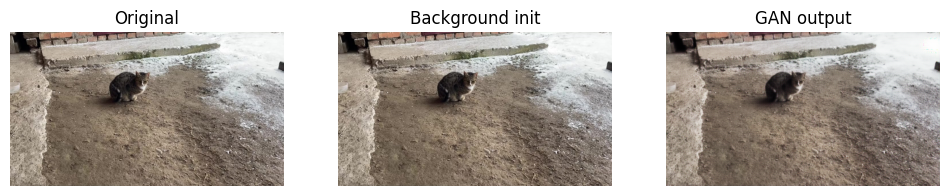

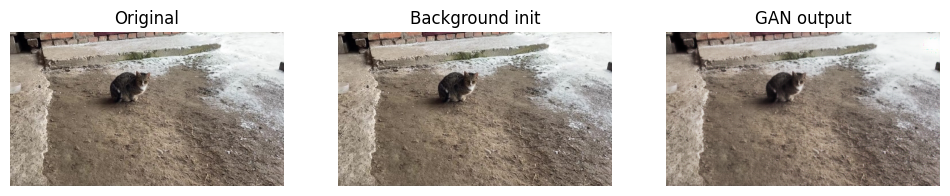

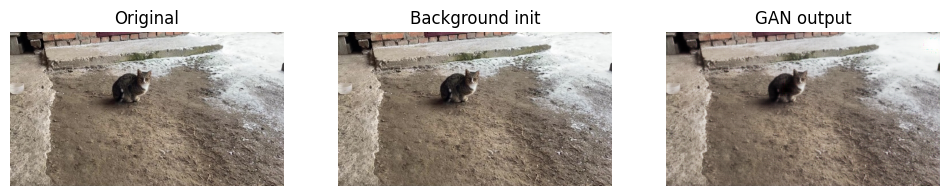

In [45]:
# =========================
# 13) Visualize a few frames
# =========================
import matplotlib.pyplot as plt

def show_triplet(i):
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(frames[i]); plt.title("Original"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(bgs[i]); plt.title("Background init"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(out_frames[i]); plt.title("GAN output"); plt.axis("off")
    plt.show()

for idx in [0, min(5, len(frames)-1), min(20, len(frames)-1)]:
    show_triplet(idx)


## Notes & extensions

### Stronger motion-awareness (GAN side)
This demo follows motion by aligning the replacement layer using the mask's oriented box each frame.

To get closer to *vid2vid* (Wang et al.), add:
- Flow-guided warping of the previous generated frame into the next input
- A flow consistency loss
- Depth/edge conditioning channels

### Making it general (not video-specific)
Train the same conditional GAN on a dataset of videos:
- Inputs: (background-with-hole, pasted replacement object, mask, optional depth/edges)
- Targets: real composites (or synthetic ground truth)
- Keep the temporal discriminator and optionally add flow losses

### Outputs
- Model checkpoint: `/kaggle/working/gan_blender.pth`
- Rendered video: `/kaggle/working/output_gan_replace.mp4`